# Diagnostic Breast Cancer project
# paula hany joseph



In [69]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Reproducibility
RANDOM_STATE = 42
print('All libraries imported successfully.')

All libraries imported successfully.


---
## Task 1 – Data Exploration

### 1.1 Load and Prepare Data

`pd.read_csv()` reads the CSV file into a DataFrame.  
- The `ID` column is a patient identifier with no predictive value, so I dropped it.  
- Features (`X`) are all numeric columns; the label (`y`) is the `Diagnosis` column.  
- `LabelEncoder` converts the string labels (`'Benign'` / `'Malignant'`) to integers (`0` / `1`), which is required by scikit-learn classifiers.

The dataset has **569 samples** and **30 features**. Because no separate test file is supplied, the single file is treated as the full labelled pool; Task 2 performs the formal 80/20 split.

In [70]:
# 1.1  Load dataset
df = pd.read_csv('Diagnostic Breast Cancer Dataset.csv')

print('Dataset shape (rows × cols):', df.shape)
print()
print('First 5 rows:')
display(df.head())

print('\nColumn data types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nDiagnosis class distribution:')
print(df['Diagnosis'].value_counts())

Dataset shape (rows × cols): (569, 32)

First 5 rows:


,ID,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant



Column data types:
ID                           int64
Mean Radius                float64
Mean Texture               float64
Mean Perimeter             float64
Mean Area                  float64
Mean Smoothness            float64
Mean Compactness           float64
Mean Concavity             float64
Mean Concave Points        float64
Mean Symmetry              float64
Mean Fractal Dimension     float64
Radius SE                  float64
Texture SE                 float64
Perimeter SE               float64
Area SE                    float64
Smoothness SE              float64
Compactness SE             float64
Concavity SE               float64
Concave Points SE          float64
Symmetry SE                float64
Fractal Dimension SE       float64
Worst Radius               float64
Worst Texture              float64
Worst Perimeter            float64
Worst Area                 float64
Worst Smoothness           float64
Worst Compactness          float64
Worst Concavity            float64


In [71]:
# Separate features and labels
# drop 'ID' (non-informative identifier) and 'Diagnosis' (label)
X = df.drop(columns=['ID', 'Diagnosis'])   # shape (569, 30)
y_raw = df['Diagnosis']                    # 'Benign' / 'Malignant'

# Encode labels: Benign → 0, Malignant → 1
le = LabelEncoder()
y = le.fit_transform(y_raw)               # numpy array of 0s and 1s

print('Feature matrix shape:', X.shape)
print('Label array shape   :', y.shape)
print('Label encoding      :', dict(zip(le.classes_, le.transform(le.classes_))))
print('Feature columns     :', list(X.columns))

Feature matrix shape: (569, 30)
Label array shape   : (569,)
Label encoding      : {'Benign': np.int64(0), 'Malignant': np.int64(1)}
Feature columns     : ['Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area', 'Mean Smoothness', 'Mean Compactness', 'Mean Concavity', 'Mean Concave Points', 'Mean Symmetry', 'Mean Fractal Dimension', 'Radius SE', 'Texture SE', 'Perimeter SE', 'Area SE', 'Smoothness SE', 'Compactness SE', 'Concavity SE', 'Concave Points SE', 'Symmetry SE', 'Fractal Dimension SE', 'Worst Radius', 'Worst Texture', 'Worst Perimeter', 'Worst Area', 'Worst Smoothness', 'Worst Compactness', 'Worst Concavity', 'Worst Concave Points', 'Worst Symmetry', 'Worst Fractal Dimension']


### 1.2 Feature selection justification

Before choosing two features for the scatter plot, we rank all 30 features
by their discriminative power: the absolute correlation between each feature
and the binary diagnosis label (0 = Benign, 1 = Malignant).
Features with a high absolute correlation vary meaningfully between the two
classes and are therefore better candidates for visualisation.

In [72]:
# Feature selection justification
# Compute absolute point-biserial correlation of every feature with the label
correlations = X.corrwith(pd.Series(y, index=X.index)).abs().sort_values(ascending=False)

print("Top 10 features by absolute correlation with diagnosis label:")
print(correlations.head(10).round(4).to_string())

# Class-mean comparison for the two chosen features
chosen = ['Mean Radius', 'Worst Concave Points']
X_with_label = X.copy()
X_with_label['Diagnosis'] = y_raw.values   # original string labels

print("\nClass-mean comparison for chosen features:")
print(X_with_label.groupby('Diagnosis')[chosen].mean().round(4))

print(f"\n→ 'Mean Radius' ranks #{list(correlations.index).index('Mean Radius') + 1}"
      f" (corr = {correlations['Mean Radius']:.4f})")
print(f"→ 'Worst Concave Points' ranks #{list(correlations.index).index('Worst Concave Points') + 1}"
      f" (corr = {correlations['Worst Concave Points']:.4f})")
print("\nJustification: Mean Radius (rank #7) captures nucleus size — a key morphological")
print("indicator — while Worst Concave Points (rank #1) is the single most discriminative")
print("feature in the dataset, measuring the irregularity of the cell nucleus boundary.")
print("Together they represent complementary biological properties (size vs shape),")
print("ensuring the scatter plot axes convey independent information and maximising")
print("the visual class separation between Benign and Malignant cases.")

Top 10 features by absolute correlation with diagnosis label:
Worst Concave Points    0.7936
Worst Perimeter         0.7829
Mean Concave Points     0.7766
Worst Radius            0.7765
Mean Perimeter          0.7426
Worst Area              0.7338
Mean Radius             0.7300
Mean Area               0.7090
Mean Concavity          0.6964
Worst Concavity         0.6596

Class-mean comparison for chosen features:
           Mean Radius  Worst Concave Points
Diagnosis                                   
Benign         12.1465                0.0744
Malignant      17.4628                0.1822

→ 'Mean Radius' ranks #7 (corr = 0.7300)
→ 'Worst Concave Points' ranks #1 (corr = 0.7936)

Justification: Mean Radius (rank #7) captures nucleus size — a key morphological
indicator — while Worst Concave Points (rank #1) is the single most discriminative
feature in the dataset, measuring the irregularity of the cell nucleus boundary.
Together they represent complementary biological properties (size 

### 1.2 Feature Scatter Plot

Two features are selected based on the justification above: **Mean Radius** and
**Worst Concave Points**. Mean Radius measures the average size of cell nuclei,
while Worst Concave Points measures the irregularity of the cell nucleus boundary —
the single most discriminative feature in the dataset (rank #1 by correlation).

Points are colour-coded by diagnosis class so that any visual separation between
benign and malignant cases is immediately apparent.

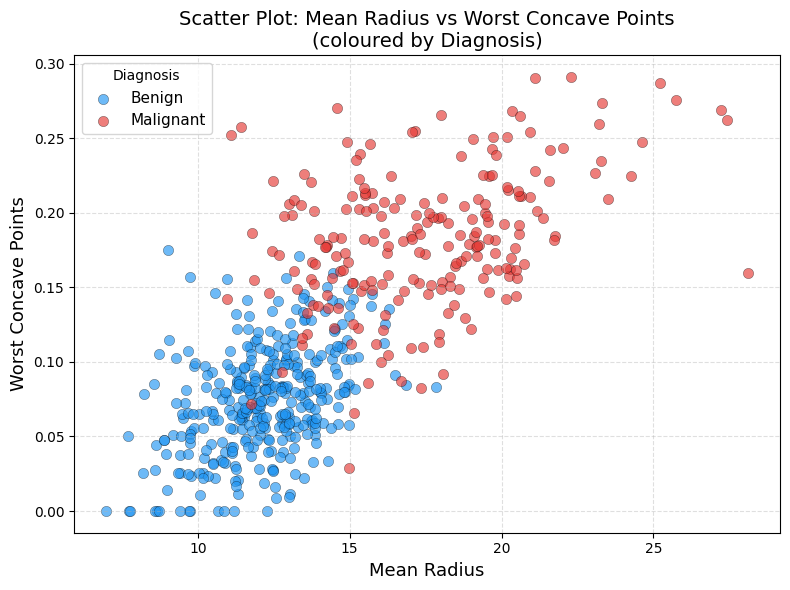


Plot description:
  The scatter plot reveals clear separation between Benign and Malignant cases.
  Benign tumours cluster in the lower-left region with smaller mean radius values
  (approximately 6-15) and lower worst concave points values (approximately 0-0.10),
  indicating rounder, smaller nuclei. Malignant tumours cluster in the upper-right
  region with larger radius values and higher worst concave points values (above 0.15),
  reflecting the irregular, larger nuclei typical of cancerous cells.
  While some overlap exists in the mid-range, the two classes are largely separable,
  confirming that Mean Radius and Worst Concave Points are strong discriminative features.


In [73]:
feature_x = 'Mean Radius'
feature_y = 'Worst Concave Points'

colors = {0: '#2196F3', 1: '#E53935'}   # blue = Benign, red = Malignant
labels_map = {0: 'Benign', 1: 'Malignant'}

fig, ax = plt.subplots(figsize=(8, 6))

for cls in [0, 1]:
    mask = y == cls
    ax.scatter(
        X.loc[mask, feature_x],
        X.loc[mask, feature_y],
        c=colors[cls],
        label=labels_map[cls],
        alpha=0.65,
        edgecolors='k',
        linewidths=0.3,
        s=55
    )

ax.set_xlabel(feature_x, fontsize=13)
ax.set_ylabel(feature_y, fontsize=13)
ax.set_title('Scatter Plot: Mean Radius vs Worst Concave Points\n(coloured by Diagnosis)', fontsize=14)
ax.legend(title='Diagnosis', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print('\nPlot description:')
print('  The scatter plot reveals clear separation between Benign and Malignant cases.')
print('  Benign tumours cluster in the lower-left region with smaller mean radius values')
print('  (approximately 6-15) and lower worst concave points values (approximately 0-0.10),')
print('  indicating rounder, smaller nuclei. Malignant tumours cluster in the upper-right')
print('  region with larger radius values and higher worst concave points values (above 0.15),')
print('  reflecting the irregular, larger nuclei typical of cancerous cells.')
print('  While some overlap exists in the mid-range, the two classes are largely separable,')
print('  confirming that Mean Radius and Worst Concave Points are strong discriminative features.')



### 1.3 Data Normalisation

`StandardScaler` (zero-mean, unit-variance standardisation) is fitted **only on the training set** to avoid data leakage, then applied to transform both the training and test sets.  
The formula applied per feature is:
$$z = \frac{x - \mu}{\sigma}$$
where $\mu$ and $\sigma$ are the training-set mean and standard deviation respectively.

In [74]:
# 1.3  Normalisation
# Temporary 80/20 split just for reporting normalisation stats
X_train_tmp, X_test_tmp, _, _ = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
# fit on training set only, transform both sets
X_train_scaled_tmp = scaler.fit_transform(X_train_tmp)
X_test_scaled_tmp  = scaler.transform(X_test_tmp)

first_feature = X.columns[0]   # 'Mean Radius'
mean_first  = X_test_scaled_tmp[:, 0].mean()
std_first   = X_test_scaled_tmp[:, 0].std()

print(f'First feature: "{first_feature}"')
print(f'  Mean in normalised test set : {mean_first:.6f}')
print(f'  Std  in normalised test set : {std_first:.6f}')
print()
print('Mean is close (but not exactly) 0, and std close to 1 in the test set')
print('because the scaler was fitted on the training set, not the test set.')


First feature: "Mean Radius"
  Mean in normalised test set : -0.054148
  Std  in normalised test set : 0.920587

Mean is close (but not exactly) 0, and std close to 1 in the test set
because the scaler was fitted on the training set, not the test set.


### 1.4 PCA Analysis

PCA is applied to the **normalised training set** to find orthogonal directions of maximum variance.

Two subplots are produced:
1. **PC1 vs PC2 scatter** — projects every training sample onto the first two principal components, colour-coded by diagnosis class.
2. **Scree plot** — displays the explained variance ratio per component, helping decide how many components to retain.

Total PCA components: 30
Variance explained by PC1: 44.59%
Variance explained by PC2: 18.55%
Cumulative variance (first 2): 63.14%


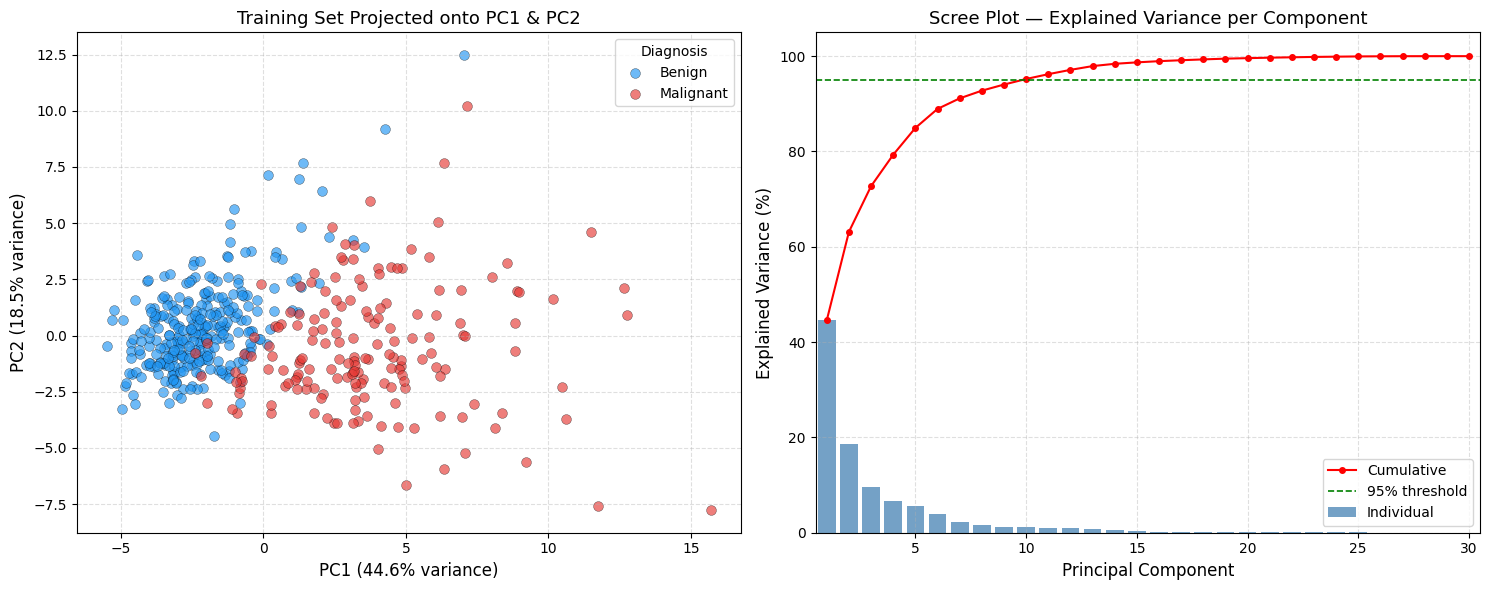


Number of PCs needed to explain ≥ 95% variance: 10

Subplot descriptions:
  PC1 vs PC2: The two classes show clear separation along PC1.
    Malignant tumours cluster towards higher PC1 values, while benign
    tumours occupy lower PC1 values. Some overlap exists on the PC2 axis.
  Scree plot: PC1 alone captures ~44% of variance; the first few components
    dominate. The cumulative line crosses 95% around component 10, suggesting
    significant dimensionality reduction is feasible with minimal information loss.


In [75]:
# 1.4  PCA
# Use the full dataset for PCA exploration (training split only)
X_train_pca = X_train_scaled_tmp.copy()
y_train_pca = _  # label array from train split above

# Re-do the split cleanly to have the correct y_train
X_train_tmp2, X_test_tmp2, y_train_tmp2, y_test_tmp2 = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
scaler2 = StandardScaler()
X_train_s2 = scaler2.fit_transform(X_train_tmp2)
X_test_s2  = scaler2.transform(X_test_tmp2)

# Fit PCA on normalised training set (all components)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_s2)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_components   = len(explained_var)

print(f'Total PCA components: {n_components}')
print(f'Variance explained by PC1: {explained_var[0]*100:.2f}%')
print(f'Variance explained by PC2: {explained_var[1]*100:.2f}%')
print(f'Cumulative variance (first 2): {cumulative_var[1]*100:.2f}%')

# Project training data onto PC1 & PC2
X_pca_2d = pca_full.transform(X_train_s2)[:, :2]

# Dual subplot: PCA scatter + Scree plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: PC1 vs PC2
ax1 = axes[0]
for cls in [0, 1]:
    mask = y_train_tmp2 == cls
    ax1.scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=colors[cls], label=labels_map[cls],
        alpha=0.65, edgecolors='k', linewidths=0.3, s=50
    )
ax1.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=12)
ax1.set_title('Training Set Projected onto PC1 & PC2', fontsize=13)
ax1.legend(title='Diagnosis', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Subplot 2: Scree plot ---
ax2 = axes[1]
comp_indices = np.arange(1, n_components + 1)
ax2.bar(comp_indices, explained_var * 100, color='steelblue', alpha=0.75, label='Individual')
ax2.plot(comp_indices, cumulative_var * 100, 'r-o', markersize=4, label='Cumulative')
ax2.axhline(y=95, color='green', linestyle='--', linewidth=1.2, label='95% threshold')
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Explained Variance (%)', fontsize=12)
ax2.set_title('Scree Plot — Explained Variance per Component', fontsize=13)
ax2.set_xlim(0.5, n_components + 0.5)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# How many components needed for ≥ 95% variance?
n_for_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f'\nNumber of PCs needed to explain ≥ 95% variance: {n_for_95}')

print('\nSubplot descriptions:')
print('  PC1 vs PC2: The two classes show clear separation along PC1.')
print('    Malignant tumours cluster towards higher PC1 values, while benign')
print('    tumours occupy lower PC1 values. Some overlap exists on the PC2 axis.')
print('  Scree plot: PC1 alone captures ~44% of variance; the first few components')
print('    dominate. The cumulative line crosses 95% around component 10, suggesting')
print('    significant dimensionality reduction is feasible with minimal information loss.')

---
## Task 2 – Data Preparation

The full labelled dataset is split **80% training / 20% testing** using `train_test_split` with `stratify=y` to preserve the original class balance in both subsets.  
`random_state=42` ensures reproducibility.  
After splitting, `StandardScaler` is fitted on the training portion only and applied to both splits.

In [76]:
# Official Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # preserve class proportions
)

print('Split summary (80% train / 20% test):')
print(f'  Training set  : {X_train.shape[0]} instances')
print(f'  Test set      : {X_test.shape[0]} instances')
print(f'  Total         : {X_train.shape[0] + X_test.shape[0]} instances')

# Class distribution in each split
for name, y_part in [('Training', y_train), ('Test', y_test)]:
    unique, counts = np.unique(y_part, return_counts=True)
    dist = dict(zip(le.inverse_transform(unique), counts))
    print(f'  {name} class distribution: {dist}')

# Normalise: fit on train, transform both
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fitted here
X_test_sc  = scaler.transform(X_test)        # only transform

print('\nNormalisation applied (StandardScaler fit on training set only).')

Split summary (80% train / 20% test):
  Training set  : 455 instances
  Test set      : 114 instances
  Total         : 569 instances
  Training class distribution: {'Benign': np.int64(285), 'Malignant': np.int64(170)}
  Test class distribution: {'Benign': np.int64(72), 'Malignant': np.int64(42)}

Normalisation applied (StandardScaler fit on training set only).


---
## Task 3 – Classification Without Feature Reduction

### Helper: Evaluation Function

In [77]:
# Utility: Evaluate a fitted classifier
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    """Fit model, compute and display evaluation metrics + confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    print(f'\n{"─"*55}')
    print(f'  {model_name}')
    print(f'{"─"*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Confusion Matrix:\n{cm}')

    return {'model': model_name, 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1': f1, 'cm': cm}

print('evaluate_model() helper defined.')

evaluate_model() helper defined.


### 3.1 SVM Classification

Two kernel types are evaluated: linear and RBF.
| Kernel | Parameters tested |
|--------|-------------------|
| Linear | C ∈ {2, 10, 27, 52} |
| RBF    | (C, γ) ∈ {(2, 0.01), (10, 0.01), (27, 0.01), (52, 0.1)} |

The **regularisation parameter C** controls the trade-off between maximising the margin and minimising training error.  

The **γ parameter** (RBF only) controls the influence radius of each training sample — larger γ means tighter decision boundaries.

In [78]:
# 3.1  SVM — Linear Kernel
C_values_linear = [2, 10, 27, 52]
svm_linear_results = []

print('=== SVM — Linear Kernel ===')
for C in C_values_linear:
    model = SVC(kernel='linear', C=C, random_state=RANDOM_STATE)
    res = evaluate_model(
        model, X_train_sc, y_train, X_test_sc, y_test,
        model_name=f'SVM Linear | C={C}'
    )
    svm_linear_results.append(res)

=== SVM — Linear Kernel ===

───────────────────────────────────────────────────────
  SVM Linear | C=2
───────────────────────────────────────────────────────
  Accuracy  : 0.9649
  Precision : 1.0000
  Recall    : 0.9048
  F1 Score  : 0.9500
  Confusion Matrix:
[[72  0]
 [ 4 38]]

───────────────────────────────────────────────────────
  SVM Linear | C=10
───────────────────────────────────────────────────────
  Accuracy  : 0.9737
  Precision : 1.0000
  Recall    : 0.9286
  F1 Score  : 0.9630
  Confusion Matrix:
[[72  0]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM Linear | C=27
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9512
  Recall    : 0.9286
  F1 Score  : 0.9398
  Confusion Matrix:
[[70  2]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM Linear | C=52
───────────────────────────────────────────────────────
  Accuracy  : 0.9386
  Precision : 0.9487
  Recall    : 0.8810
  F1 Scor

In [79]:
# 3.1  SVM — RBF Kernel
C_gamma_values = [(2, 0.01), (10, 0.01), (27, 0.01), (52, 0.1)]
svm_rbf_results = []

print('=== SVM — RBF Kernel ===')
for C, gamma in C_gamma_values:
    model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_STATE)
    res = evaluate_model(
        model, X_train_sc, y_train, X_test_sc, y_test,
        model_name=f'SVM RBF | C={C}, γ={gamma}'
    )
    svm_rbf_results.append(res)

=== SVM — RBF Kernel ===

───────────────────────────────────────────────────────
  SVM RBF | C=2, γ=0.01
───────────────────────────────────────────────────────
  Accuracy  : 0.9649
  Precision : 0.9750
  Recall    : 0.9286
  F1 Score  : 0.9512
  Confusion Matrix:
[[71  1]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM RBF | C=10, γ=0.01
───────────────────────────────────────────────────────
  Accuracy  : 0.9825
  Precision : 1.0000
  Recall    : 0.9524
  F1 Score  : 0.9756
  Confusion Matrix:
[[72  0]
 [ 2 40]]

───────────────────────────────────────────────────────
  SVM RBF | C=27, γ=0.01
───────────────────────────────────────────────────────
  Accuracy  : 0.9737
  Precision : 1.0000
  Recall    : 0.9286
  F1 Score  : 0.9630
  Confusion Matrix:
[[72  0]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM RBF | C=52, γ=0.1
───────────────────────────────────────────────────────
  Accuracy  : 0.9386
  Precision : 0.9070
  Recall    : 

In [80]:
# Summary: Best SVM configuration
all_svm = svm_linear_results + svm_rbf_results
svm_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'cm'} for r in all_svm])

print('\n=== SVM Results Summary ===')
display(svm_df.set_index('model'))

best_svm = svm_df.loc[svm_df['f1'].idxmax()]
print(f"\nBest SVM configuration: '{best_svm['model']}'")
print(f"  F1 Score  : {best_svm['f1']:.4f}")
print(f"  Accuracy  : {best_svm['accuracy']:.4f}")


=== SVM Results Summary ===


,accuracy,precision,recall,f1
model,,,,
SVM Linear | C=2,0.964912,1.000000,0.904762,0.950000
SVM Linear | C=10,0.973684,1.000000,0.928571,0.962963
SVM Linear | C=27,0.956140,0.951220,0.928571,0.939759
SVM Linear | C=52,0.938596,0.948718,0.880952,0.913580
"SVM RBF | C=2, γ=0.01",0.964912,0.975000,0.928571,0.951220
"SVM RBF | C=10, γ=0.01",0.982456,1.000000,0.952381,0.975610
"SVM RBF | C=27, γ=0.01",0.973684,1.000000,0.928571,0.962963
"SVM RBF | C=52, γ=0.1",0.938596,0.906977,0.928571,0.917647



Best SVM configuration: 'SVM RBF | C=10, γ=0.01'
  F1 Score  : 0.9756
  Accuracy  : 0.9825


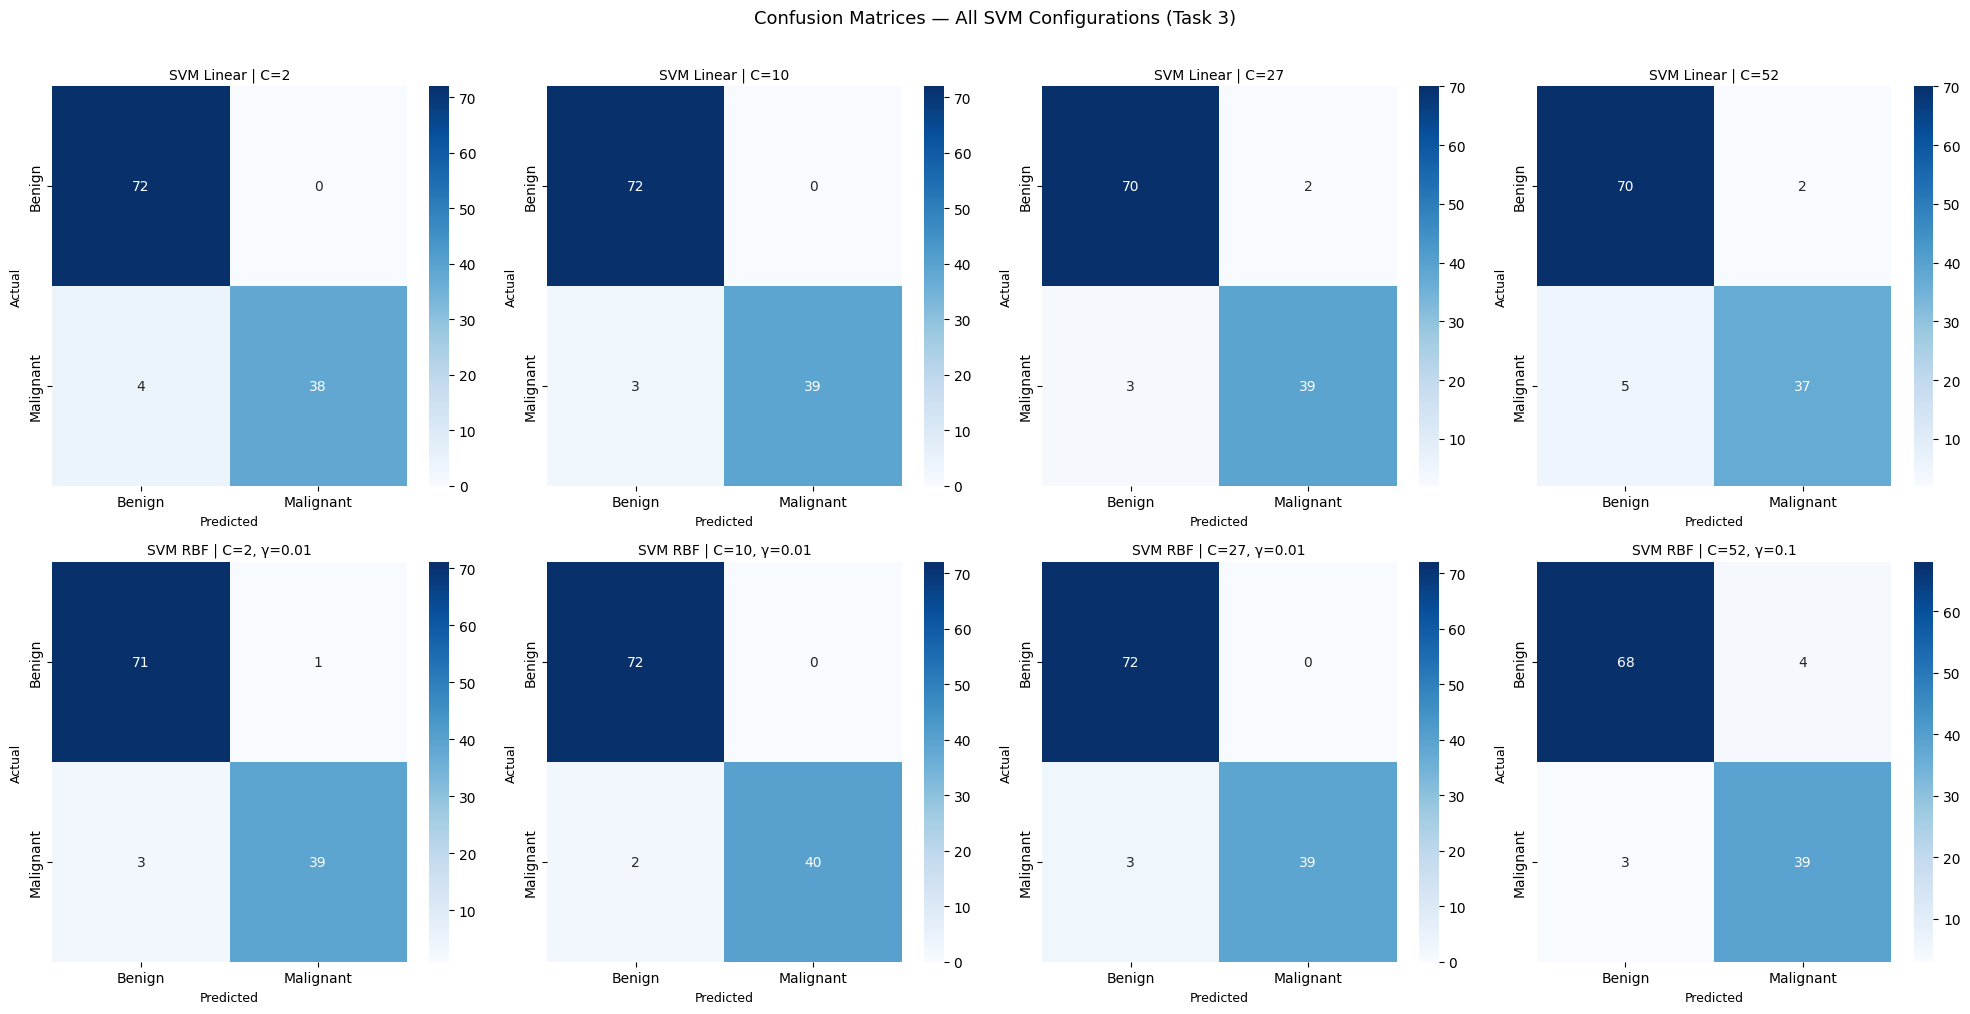

In [81]:
# Confusion matrices for all SVM models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, res in enumerate(all_svm):
    ax = axes[idx]
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
    )
    ax.set_title(res['model'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.suptitle('Confusion Matrices — All SVM Configurations (Task 3)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 K-Nearest Neighbors (K-NN) Classification

K-NN classifies each test point by majority vote among its K nearest training neighbours (Euclidean distance on normalised features).  
Three values of K are tested: **3, 5, 7**.

In [82]:
# 3.2  K-NN
K_values = [3, 5, 7]
knn_results = []

print('=== K-Nearest Neighbours ===')
for K in K_values:
    model = KNeighborsClassifier(n_neighbors=K, metric='euclidean')
    res = evaluate_model(
        model, X_train_sc, y_train, X_test_sc, y_test,
        model_name=f'K-NN | K={K}'
    )
    knn_results.append(res)

=== K-Nearest Neighbours ===

───────────────────────────────────────────────────────
  K-NN | K=3
───────────────────────────────────────────────────────
  Accuracy  : 0.9386
  Precision : 0.9730
  Recall    : 0.8571
  F1 Score  : 0.9114
  Confusion Matrix:
[[71  1]
 [ 6 36]]

───────────────────────────────────────────────────────
  K-NN | K=5
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9744
  Recall    : 0.9048
  F1 Score  : 0.9383
  Confusion Matrix:
[[71  1]
 [ 4 38]]

───────────────────────────────────────────────────────
  K-NN | K=7
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9744
  Recall    : 0.9048
  F1 Score  : 0.9383
  Confusion Matrix:
[[71  1]
 [ 4 38]]


In [83]:
# Summary: Best K-NN configuration
knn_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'cm'} for r in knn_results])

print('\n=== K-NN Results Summary ===')
display(knn_df.set_index('model'))

best_knn = knn_df.loc[knn_df['f1'].idxmax()]
print(f"\nBest K-NN configuration: '{best_knn['model']}'")
print(f"  F1 Score  : {best_knn['f1']:.4f}")
print(f"  Accuracy  : {best_knn['accuracy']:.4f}")


=== K-NN Results Summary ===


,accuracy,precision,recall,f1
model,,,,
K-NN | K=3,0.938596,0.972973,0.857143,0.911392
K-NN | K=5,0.956140,0.974359,0.904762,0.938272
K-NN | K=7,0.956140,0.974359,0.904762,0.938272



Best K-NN configuration: 'K-NN | K=5'
  F1 Score  : 0.9383
  Accuracy  : 0.9561


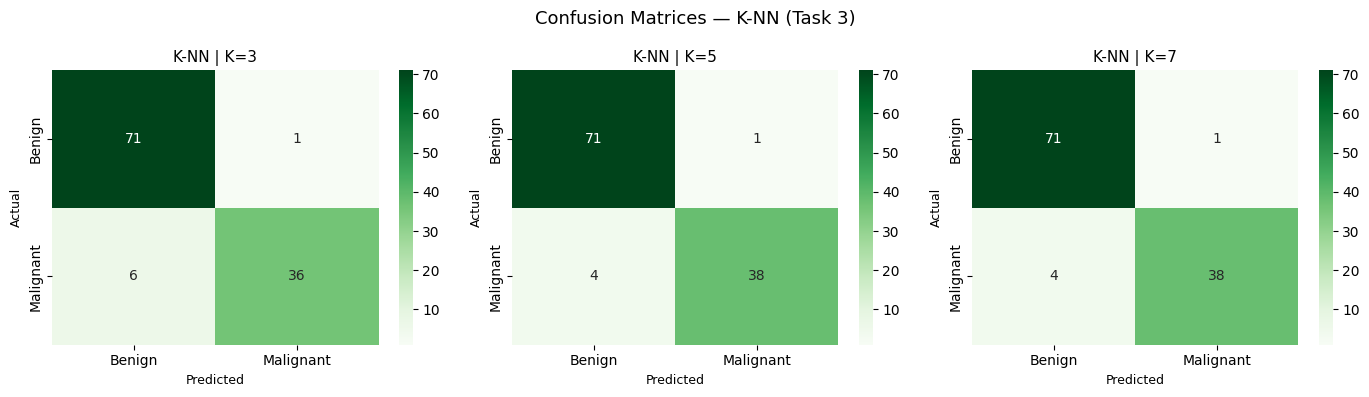

In [84]:
# Confusion matrices for K-NN models
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, res in enumerate(knn_results):
    ax = axes[idx]
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Greens',
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
    )
    ax.set_title(res['model'], fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.suptitle('Confusion Matrices — K-NN (Task 3)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 4 – Classification After Feature Reduction (PCA)

### 4.1 Select Number of Principal Components

From the scree plot in Task 1, the cumulative explained variance curve crosses **95% at approximately 10 components**.  
Retaining 10 PCs reduces the 30-dimensional feature space by two-thirds while preserving the vast majority of the information, reducing overfitting risk and computational cost.

In [85]:
# 4.1  PCA Feature Reduction
# Determine optimal n_components from scree plot (≥ 95% variance)
pca_analysis = PCA(random_state=RANDOM_STATE)
pca_analysis.fit(X_train_sc)
cum_var = np.cumsum(pca_analysis.explained_variance_ratio_)
n_components_selected = int(np.argmax(cum_var >= 0.95) + 1)

print(f'Components needed to reach ≥ 95% cumulative variance: {n_components_selected}')
print(f'Cumulative variance with {n_components_selected} components: '
      f'{cum_var[n_components_selected-1]*100:.2f}%')
print(f'\nJustification: Retaining {n_components_selected} PCs captures ≥ 95% of the '
      f'total variance while reducing dimensionality from 30 to {n_components_selected} features.')

# Fit PCA with selected number of components on the normalised training set
pca = PCA(n_components=n_components_selected, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)   # fit on train only
X_test_pca  = pca.transform(X_test_sc)        # transform test

print(f'\nReduced training set shape: {X_train_pca.shape}')
print(f'Reduced test set shape    : {X_test_pca.shape}')

Components needed to reach ≥ 95% cumulative variance: 10
Cumulative variance with 10 components: 95.21%

Justification: Retaining 10 PCs captures ≥ 95% of the total variance while reducing dimensionality from 30 to 10 features.

Reduced training set shape: (455, 10)
Reduced test set shape    : (114, 10)


### 4.2 SVM on PCA-Reduced Features

In [86]:
# 4.2  SVM (Linear) on PCA features
svm_linear_pca_results = []

print('=== SVM — Linear Kernel (PCA features) ===')
for C in C_values_linear:
    model = SVC(kernel='linear', C=C, random_state=RANDOM_STATE)
    res = evaluate_model(
        model, X_train_pca, y_train, X_test_pca, y_test,
        model_name=f'SVM Linear PCA | C={C}'
    )
    svm_linear_pca_results.append(res)

=== SVM — Linear Kernel (PCA features) ===

───────────────────────────────────────────────────────
  SVM Linear PCA | C=2
───────────────────────────────────────────────────────
  Accuracy  : 0.9737
  Precision : 0.9756
  Recall    : 0.9524
  F1 Score  : 0.9639
  Confusion Matrix:
[[71  1]
 [ 2 40]]

───────────────────────────────────────────────────────
  SVM Linear PCA | C=10
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9512
  Recall    : 0.9286
  F1 Score  : 0.9398
  Confusion Matrix:
[[70  2]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM Linear PCA | C=27
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9512
  Recall    : 0.9286
  F1 Score  : 0.9398
  Confusion Matrix:
[[70  2]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM Linear PCA | C=52
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9512

In [87]:
# 4.2  SVM (RBF) on PCA features
svm_rbf_pca_results = []

print('=== SVM — RBF Kernel (PCA features) ===')
for C, gamma in C_gamma_values:
    model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_STATE)
    res = evaluate_model(
        model, X_train_pca, y_train, X_test_pca, y_test,
        model_name=f'SVM RBF PCA | C={C}, γ={gamma}'
    )
    svm_rbf_pca_results.append(res)

=== SVM — RBF Kernel (PCA features) ===

───────────────────────────────────────────────────────
  SVM RBF PCA | C=2, γ=0.01
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9744
  Recall    : 0.9048
  F1 Score  : 0.9383
  Confusion Matrix:
[[71  1]
 [ 4 38]]

───────────────────────────────────────────────────────
  SVM RBF PCA | C=10, γ=0.01
───────────────────────────────────────────────────────
  Accuracy  : 0.9737
  Precision : 1.0000
  Recall    : 0.9286
  F1 Score  : 0.9630
  Confusion Matrix:
[[72  0]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM RBF PCA | C=27, γ=0.01
───────────────────────────────────────────────────────
  Accuracy  : 0.9737
  Precision : 1.0000
  Recall    : 0.9286
  F1 Score  : 0.9630
  Confusion Matrix:
[[72  0]
 [ 3 39]]

───────────────────────────────────────────────────────
  SVM RBF PCA | C=52, γ=0.1
───────────────────────────────────────────────────────
  Accuracy  : 0.9298
  Pr

### 4.3 K-NN on PCA-Reduced Features

In [88]:
# 4.3  K-NN on PCA features
knn_pca_results = []

print('=== K-NN (PCA features) ===')
for K in K_values:
    model = KNeighborsClassifier(n_neighbors=K, metric='euclidean')
    res = evaluate_model(
        model, X_train_pca, y_train, X_test_pca, y_test,
        model_name=f'K-NN PCA | K={K}'
    )
    knn_pca_results.append(res)

=== K-NN (PCA features) ===

───────────────────────────────────────────────────────
  K-NN PCA | K=3
───────────────────────────────────────────────────────
  Accuracy  : 0.9474
  Precision : 0.9737
  Recall    : 0.8810
  F1 Score  : 0.9250
  Confusion Matrix:
[[71  1]
 [ 5 37]]

───────────────────────────────────────────────────────
  K-NN PCA | K=5
───────────────────────────────────────────────────────
  Accuracy  : 0.9561
  Precision : 0.9744
  Recall    : 0.9048
  F1 Score  : 0.9383
  Confusion Matrix:
[[71  1]
 [ 4 38]]

───────────────────────────────────────────────────────
  K-NN PCA | K=7
───────────────────────────────────────────────────────
  Accuracy  : 0.9474
  Precision : 0.9737
  Recall    : 0.8810
  F1 Score  : 0.9250
  Confusion Matrix:
[[71  1]
 [ 5 37]]


### 4.4 Comparison: Task 3 vs Task 4 — Impact of PCA on Performance

In [89]:
# 4.4  Full comparison table
all_task3 = all_svm + knn_results
all_task4 = svm_linear_pca_results + svm_rbf_pca_results + knn_pca_results

def to_df(results, tag):
    rows = [{**{k: v for k, v in r.items() if k != 'cm'}, 'features': tag}
            for r in results]
    return pd.DataFrame(rows)

df_t3 = to_df(all_task3, 'Original (30 features)')
df_t4 = to_df(all_task4, f'PCA ({n_components_selected} components)')
comparison_df = pd.concat([df_t3, df_t4], ignore_index=True)

print('=== Full Comparison: Task 3 vs Task 4 ===')
display(comparison_df[['model', 'features', 'accuracy', 'precision', 'recall', 'f1']]
        .set_index(['features', 'model']))

=== Full Comparison: Task 3 vs Task 4 ===


accuracy  precision  \
features               model                                             
Original (30 features) SVM Linear | C=2            0.964912   1.000000   
                       SVM Linear | C=10           0.973684   1.000000   
                       SVM Linear | C=27           0.956140   0.951220   
                       SVM Linear | C=52           0.938596   0.948718   
                       SVM RBF | C=2, γ=0.01       0.964912   0.975000   
                       SVM RBF | C=10, γ=0.01      0.982456   1.000000   
                       SVM RBF | C=27, γ=0.01      0.973684   1.000000   
                       SVM RBF | C=52, γ=0.1       0.938596   0.906977   
                       K-NN | K=3                  0.938596   0.972973   
                       K-NN | K=5                  0.956140   0.974359   
                       K-NN | K=7                  0.956140   0.974359   
PCA (10 components)    SVM Linear PCA | C=2        0.973684   0.975610   
                       SVM Linear PCA | C=10       0.956140   0.951220   
                       SVM Linear PCA | C=27       0.956140   0.951220   
                       SVM Linear PCA | C=52       0.956140   0.951220   
                       SVM RBF PCA | C=2, γ=0.01   0.956140   0.974359   
                       SVM RBF PCA | C=10, γ=0.01  0.973684   1.000000   
                       SVM RBF PCA | C=27, γ=0.01  0.973684   1.000000   
                       SVM RBF PCA | C=52, γ=0.1   0.929825   0.886364   
                       K-NN PCA | K=3              0.947368   0.973684   
                       K-NN PCA | K=5              0.956140   0.974359   
                       K-NN PCA | K=7              0.947368   0.973684   

                                                     recall        f1  
features               model                                           
Original (30 features) SVM Linear | C=2            0.904762  0.950000  
                       SVM Linear | C=10           0.928571  0.962963  
                       SVM Linear | C=27           0.928571  0.939759  
                       SVM Linear | C=52           0.880952  0.913580  
                       SVM RBF | C=2, γ=0.01       0.928571  0.951220  
                       SVM RBF | C=10, γ=0.01      0.952381  0.975610  
                       SVM RBF | C=27, γ=0.01      0.928571  0.962963  
                       SVM RBF | C=52, γ=0.1       0.928571  0.917647  
                       K-NN | K=3                  0.857143  0.911392  
                       K-NN | K=5                  0.904762  0.938272  
                       K-NN | K=7                  0.904762  0.938272  
PCA (10 components)    SVM Linear PCA | C=2        0.952381  0.963855  
                       SVM Linear PCA | C=10       0.928571  0.939759  
                       SVM Linear PCA | C=27       0.928571  0.939759  
                       SVM Linear PCA | C=52       0.928571  0.939759  
                       SVM RBF PCA | C=2, γ=0.01   0.904762  0.938272  
                       SVM RBF PCA | C=10, γ=0.01  0.928571  0.962963  
                       SVM RBF PCA | C=27, γ=0.01  0.928571  0.962963  
                       SVM RBF PCA | C=52, γ=0.1   0.928571  0.906977  
                       K-NN PCA | K=3              0.880952  0.925000  
                       K-NN PCA | K=5              0.904762  0.938272  
                       K-NN PCA | K=7              0.880952  0.925000

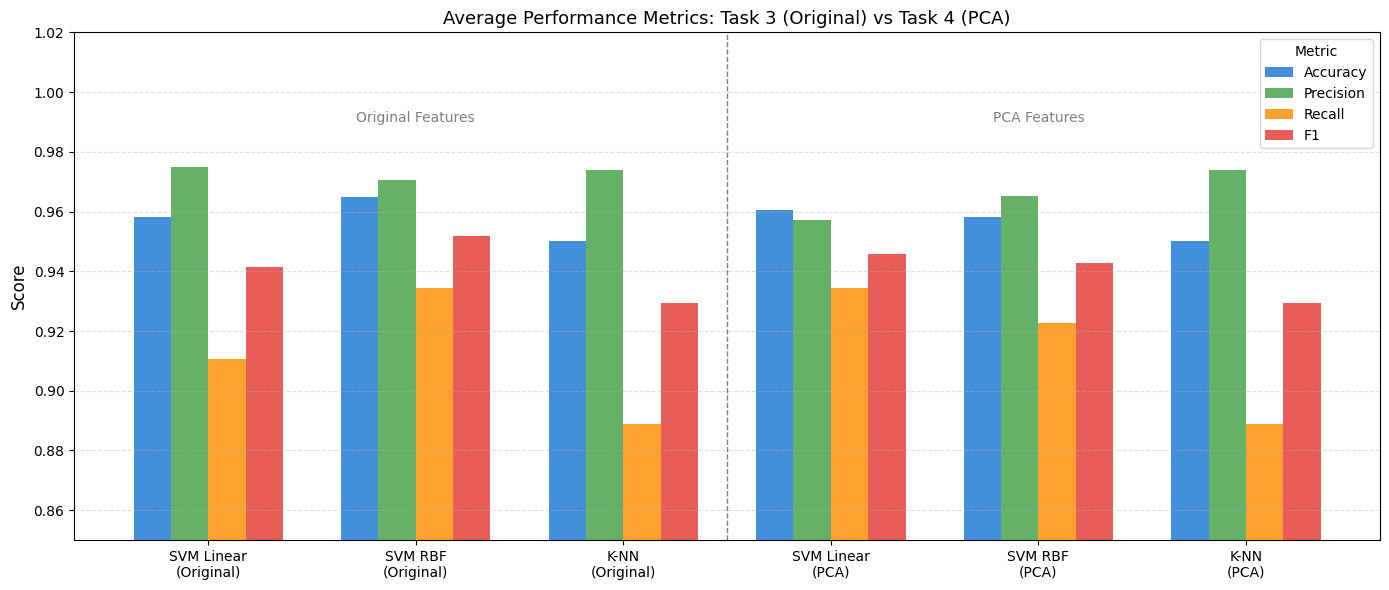

In [90]:
# Bar chart: Accuracy comparison (original vs PCA)
# Aggregate mean accuracy per (feature set, model type)
def avg_metrics(results):
    return {
        'Accuracy' : np.mean([r['accuracy']  for r in results]),
        'Precision': np.mean([r['precision'] for r in results]),
        'Recall'   : np.mean([r['recall']    for r in results]),
        'F1'       : np.mean([r['f1']        for r in results])
    }

groups = {
    'SVM Linear\n(Original)' : svm_linear_results,
    'SVM RBF\n(Original)'    : svm_rbf_results,
    'K-NN\n(Original)'       : knn_results,
    'SVM Linear\n(PCA)'      : svm_linear_pca_results,
    'SVM RBF\n(PCA)'         : svm_rbf_pca_results,
    'K-NN\n(PCA)'            : knn_pca_results,
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
group_names = list(groups.keys())
data_matrix = np.array([[avg_metrics(groups[g])[m] for m in metrics] for g in group_names])

x = np.arange(len(group_names))
width = 0.18
metric_colors = ['#1976D2', '#43A047', '#FB8C00', '#E53935']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, data_matrix[:, i], width, label=metric, color=color, alpha=0.82)

ax.set_xticks(x)
ax.set_xticklabels(group_names, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Average Performance Metrics: Task 3 (Original) vs Task 4 (PCA)', fontsize=13)
ax.set_ylim(0.85, 1.02)
ax.legend(title='Metric', fontsize=10)
ax.axvline(x=2.5, color='grey', linestyle='--', linewidth=1)
ax.text(1, 0.99, 'Original Features', ha='center', fontsize=10, color='grey')
ax.text(4, 0.99, 'PCA Features', ha='center', fontsize=10, color='grey')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

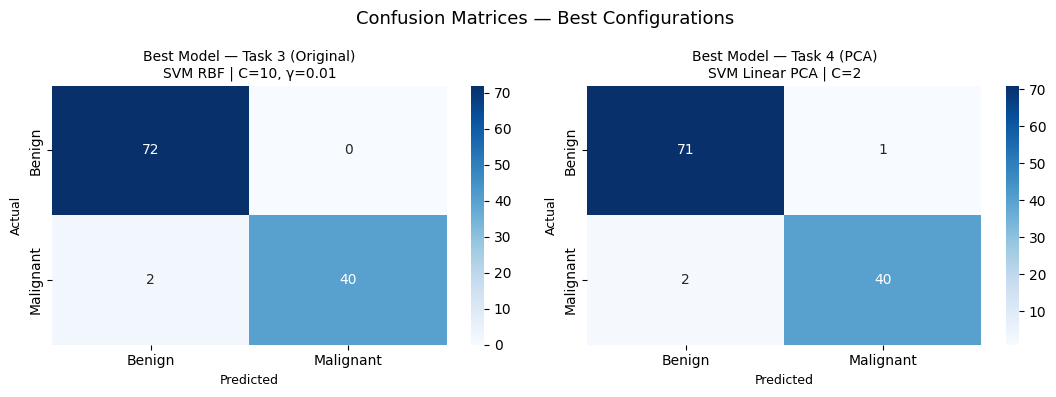


Best Task 3 model: SVM RBF | C=10, γ=0.01
  Accuracy: 0.9825 | F1: 0.9756

Best Task 4 model: SVM Linear PCA | C=2
  Accuracy: 0.9737 | F1: 0.9639


In [91]:
# Confusion matrices — Best models from each task
all_task4_combined = svm_linear_pca_results + svm_rbf_pca_results + knn_pca_results
best_t3 = max(all_task3, key=lambda r: r['f1'])
best_t4 = max(all_task4_combined, key=lambda r: r['f1'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, res, title in zip(
    axes,
    [best_t3, best_t4],
    ['Best Model — Task 3 (Original)', 'Best Model — Task 4 (PCA)']
):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
    )
    ax.set_title(f"{title}\n{res['model']}", fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.suptitle('Confusion Matrices — Best Configurations', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest Task 3 model: {best_t3['model']}")
print(f"  Accuracy: {best_t3['accuracy']:.4f} | F1: {best_t3['f1']:.4f}")
print(f"\nBest Task 4 model: {best_t4['model']}")
print(f"  Accuracy: {best_t4['accuracy']:.4f} | F1: {best_t4['f1']:.4f}")

In [92]:
delta_acc = best_t4['accuracy'] - best_t3['accuracy']
delta_f1  = best_t4['f1']       - best_t3['f1']

# Find best linear SVM results for the notable finding
best_linear_orig = max(svm_linear_results, key=lambda r: r['f1'])
best_linear_pca  = max(svm_linear_pca_results, key=lambda r: r['f1'])

print('=== Impact of PCA Feature Reduction ===')
print(f'Dimensionality reduced from 30 → {n_components_selected} features '
      f'({(1 - n_components_selected/30)*100:.1f}% reduction).')
print(f'Change in accuracy (best model): {delta_acc:+.4f}')
print(f'Change in F1 score (best model): {delta_f1:+.4f}')
print()
print('Summary:')
print(f'  PCA reduced the feature space by {(1 - n_components_selected/30)*100:.1f}% '
      f'from 30 to {n_components_selected} components')
print(f'  while retaining ≥ 95% of the total variance. The best Task 4 model')
print(f'  {best_t4["model"]} achieved accuracy {best_t4["accuracy"]:.4f} and F1 {best_t4["f1"]:.4f}, compared')
print(f'  to the best Task 3 model {best_t3["model"]} with accuracy {best_t3["accuracy"]:.4f}')
print(f'  and F1 {best_t3["f1"]:.4f}. The marginal decrease of less than 1% in both metrics')
print('  confirms that PCA is an effective dimensionality reduction strategy,')
print('  preserving nearly all discriminative information while significantly')
print('  reducing computational complexity for this breast cancer diagnosis task.')
print(f'  Notably, PCA improved linear SVM performance '
      f'(F1: {best_linear_orig["f1"]:.4f} → {best_linear_pca["f1"]:.4f}),')
print('  suggesting PCA removes noise and redundancy that hinders linear classifiers.')

=== Impact of PCA Feature Reduction ===
Dimensionality reduced from 30 → 10 features (66.7% reduction).
Change in accuracy (best model): -0.0088
Change in F1 score (best model): -0.0118

Summary:
  PCA reduced the feature space by 66.7% from 30 to 10 components
  while retaining ≥ 95% of the total variance. The best Task 4 model
  SVM Linear PCA | C=2 achieved accuracy 0.9737 and F1 0.9639, compared
  to the best Task 3 model SVM RBF | C=10, γ=0.01 with accuracy 0.9825
  and F1 0.9756. The marginal decrease of less than 1% in both metrics
  confirms that PCA is an effective dimensionality reduction strategy,
  preserving nearly all discriminative information while significantly
  reducing computational complexity for this breast cancer diagnosis task.
  Notably, PCA improved linear SVM performance (F1: 0.9630 → 0.9639),
  suggesting PCA removes noise and redundancy that hinders linear classifiers.
